## 2.10 金利スプレッド

- Data : data/QUARTERLY.csv ~ 長期金利（国債、５年物）`r5`, 短期金利（T-Bill、３か月物）`tbill`

- ボックス=ジェンキンスのモデル選択法を学ぶ。
- 彼らの方法は、第１段階で、標本ACF・PACFを理論上のACF・PACFと比較することでモデルを特定する。第２段階では、候補となるモデルを推定し、係数の推定値を分析する。第３段階では、推定モデルからの残差がホワイトノイズかを診断することで、モデルの妥当性を評価する。この診断にパスすれば、推定モデルは適切とみなされ予測に用いられる。

#### データ処理

In [16]:
import pandas as pd

data = pd.read_csv('/home/ikuyoshi/TimeSeries/data/QUARTERLY.csv', 
                   sep=';',
                   decimal=',',
                   index_col=0,  # index_col=0 to use the first column as the index
                   parse_dates=True, # parse_dates=True to parse the index as dates
                   )
data.head()

/tmp/ipykernel_60375/828768958.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv('/home/ikuyoshi/TimeSeries/data/QUARTERLY.csv',


,ffr,tbill,tb1yr,r5,r10,ppinsa,finished,cpi,cpicore,m1nsa,m2sa,m2nsa,unemp,indprod,rgpdp,potent,deflator,curr
1960-01-01,3.93,3.87,4.57,4.64,4.49,31.67,33.20,29.40,18.92,140.53,896.1,299.40,5.13,23.93,2845.3,2824.2,18.521,31.8
1960-04-01,3.70,2.99,3.87,4.30,4.26,31.73,33.40,29.57,19.00,138.40,903.3,300.03,5.23,23.41,2832.0,2851.2,18.579,31.9
1960-07-01,2.94,2.36,3.07,3.67,3.83,31.63,33.43,29.59,19.07,139.60,919.4,305.50,5.53,23.02,2836.6,2878.7,18.648,32.2
1960-10-01,2.30,2.31,2.99,3.75,3.89,31.70,33.67,29.78,19.14,142.67,932.8,312.30,6.27,22.47,2800.2,2906.7,18.700,32.6
1961-01-01,2.00,2.35,2.87,3.64,3.79,31.80,33.63,29.84,19.17,142.23,948.9,317.10,6.80,22.13,2816.9,2934.8,18.743,32.1


In [17]:
# 金利スプレッドを定義
data['spread'] = data['r5'] - data['tbill']
print(data['spread'].describe())

count    212.00000
mean       1.21250
std        0.95442
min       -1.19000
25%        0.50000
50%        1.23000
75%        1.99500
max        3.79000
Name: spread, dtype: float64


In [18]:
# 今回使うデータフレームの作成
data_spread = data[['spread', 'r5', 'tbill']]
print(data_spread.head())

            spread    r5  tbill
1960-01-01    0.77  4.64   3.87
1960-04-01    1.31  4.30   2.99
1960-07-01    1.31  3.67   2.36
1960-10-01    1.44  3.75   2.31
1961-01-01    1.29  3.64   2.35


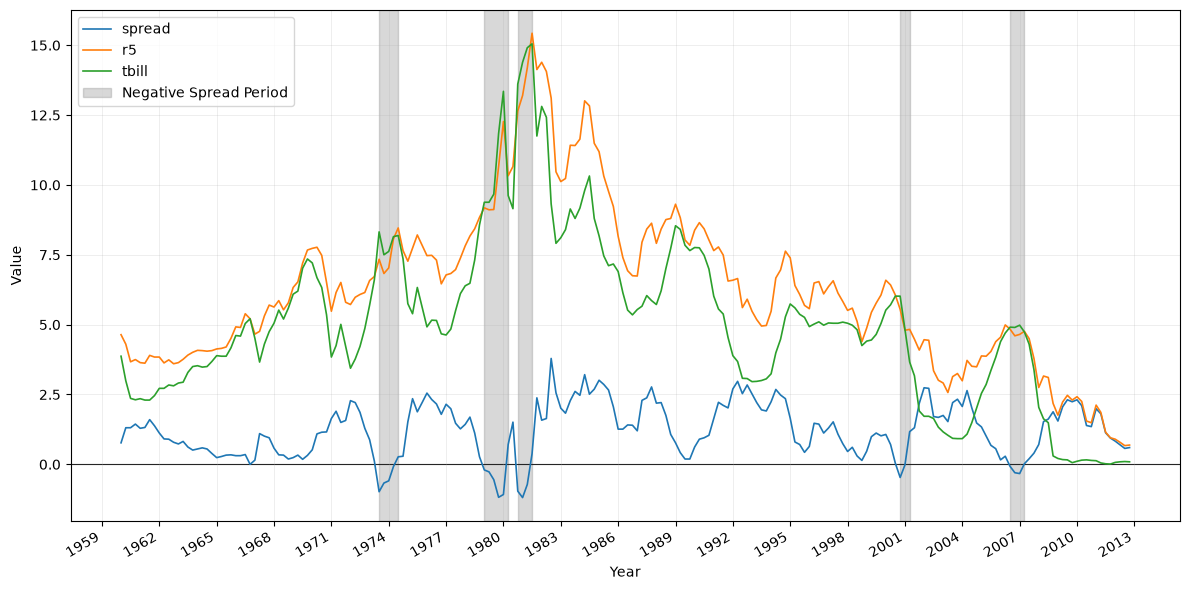

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 6))

# 複数の時系列を重ねて描画
for col in data_spread.columns:
    ax.plot(data_spread.index, data_spread[col], label=col, linewidth=1.2)

# y = 0 の水平線を描画
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-', zorder=1)

# 通常のグリッド
ax.grid(True, alpha=0.3, linewidth=0.5)

# x軸ラベルを３年ごとに配置
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# スプレッドが負の期間を強調
is_neg = data_spread['spread'] < 0  
change = is_neg.astype(int).diff().fillna(0)  # スプレッドが負から正に変わるときは1、正から負に変わるときは-1、それ以外は0
starts = data_spread.index[change == 1]
ends = data_spread.index[change == -1]

for start, end in zip(starts, ends):
    ax.axvspan(start, end, color='gray', alpha=0.3, zorder=0)  # axvspan メソッドは、指定した x 軸の範囲を塗る。

# 凡例の追加
neg_patch = mpatches.Patch(color='gray', alpha=0.3, label='Negative Spread Period')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles +[neg_patch], loc='best')
ax.set_xlabel('Year')
ax.set_ylabel('Value')
fig.autofmt_xdate()  # x軸のラベルを自動で回転

plt.tight_layout()
plt.show()

- 金利スプレッドの標本平均は 1.21 である。
- 一般的に、長期金利のほうが短期金利よりも高いため、スプレッドは正になることが多い。
- 長期金利、短期金利ともに上昇局面のときにスプレッドが負になることが多い。
- スプレッドの系列を見ると構造変化はないように見えるため、定常系列と考えてよさそうである。

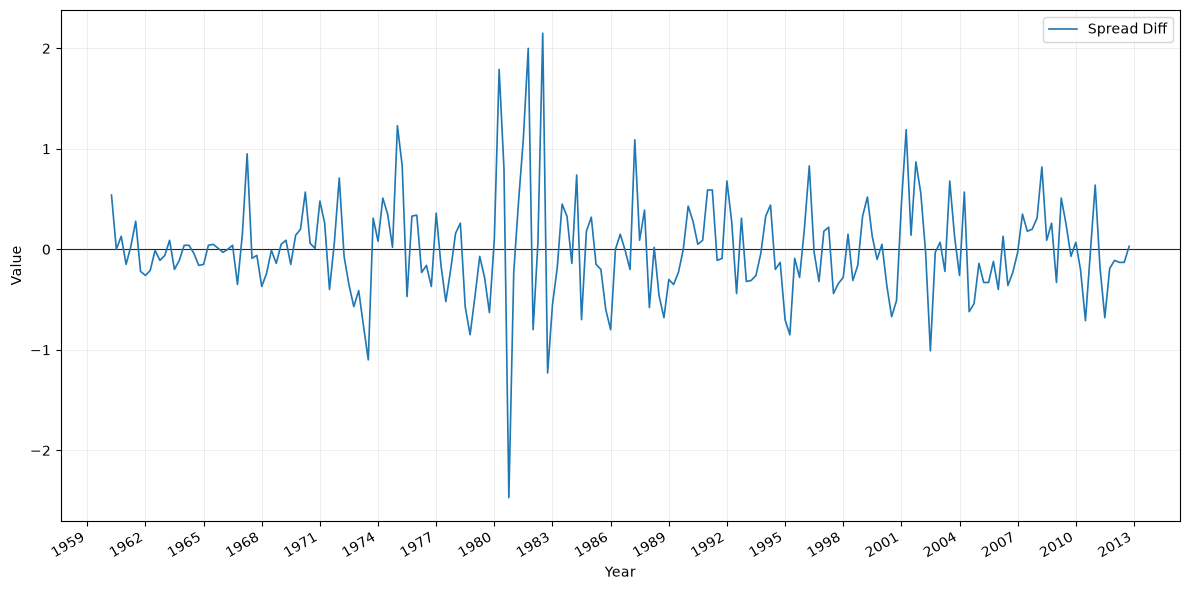

In [20]:
# スプレッドの階差を取ってみる

data_spread['spread_diff'] = data_spread['spread'].diff()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(data_spread.index, data_spread['spread_diff'], label='Spread Diff', linewidth=1.2)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-', zorder=1)
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='best')
ax.set_xlabel('Year')
ax.set_ylabel('Value')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


- スプレッドの1階の階差の動きはかなり不規則であり、重要な情報はなさそうである。したがって、階差を取る前のスプレッドの系列 $\{s_t\}$ を用いるほうが合理的。
- しかし、$s_t$ には大きな正（負）のジャンプが存在しているため、DGPが正規分布である仮定は妥当ではない可能性がある。
- したがって、分析者によってはそうした変動を小さくする変換を望むかもしれない。例えば、対数や平方根を取ると大きな値は小さく、小さな値は大きく評価されるため、変動は全体的に小さくなる。
- しかし、$s_t$ は負にもなりえるので、そのままでは対数変換や平方根変換はできない。そこで、正の定数 $c$ を用いて、すべての $t$ について $s_t + c > 0$ となるように $\ln (s_t + c)$ もしくは $(s_t + c)^{1/2}$ とすれば変換は可能となる。$s_t$ の図をみると $c=3$ とすればよい。
- データ分析の際は、DGPが前提条件を満たすかどうか確認する必要がある。

### 同定（Identification）

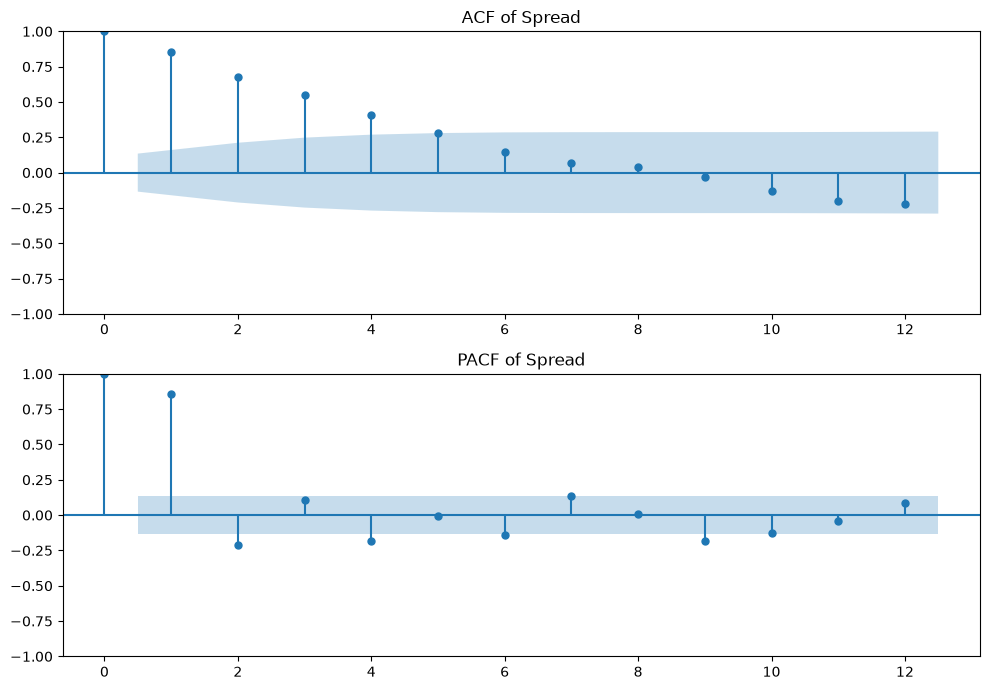

In [21]:
# ACFとPACFの描画

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1,figsize=(10, 7))  # 2行1列のサブプロットを作成, axesは2つのAxesオブジェクトの配列

plot_acf(data_spread['spread'].dropna(), lags=12, ax=axes[0])  
axes[0].set_title('ACF of Spread')

plot_pacf(data_spread['spread'].dropna(), lags=12, ax=axes[1], method='ywm')  # method='ywm'はYule-Walker法を使用してPACFを計算する
axes[1].set_title('PACF of Spread')

plt.tight_layout()
plt.show()

- 影付きの領域は、「真の自己相関が0である」という帰無仮説の下での95％信頼区間。バーがこの帯の外に出ている時点（ラグ）は、統計的に有意な自己相関がある（あるいはホワイトノイズでは説明できない構造がある）と判断される目安となる。  
- 理論上のACFとPACFの性質は以下である。  
  
|DGP|ACFの形状|PACFの形状|  
|---|---|---|  
|ホワイトノイズ|すべてのラグで自己相関ゼロ|すべてのラグで偏自己相関ゼロ|  
|AR(p)|緩やかに減衰。係数は振動するかもしれない|次数 $p$ で急激に打ち切り、それ以降は偏自己相関はゼロ|  
|MA(q)|次数 $q$ で急激に打ち切り|緩やかに減衰。係数は振動するかもしれない|  
|ARMA(p,q)|次数 $q+1$ から、一様もしくは振動しながら減衰する|次数 $p+1$ から、一様または振動しながら減衰する|  

- ACF は緩やかに減衰し、PACF は急激に打ち切られているので MA 過程やホワイトノイズではなさそうである。
- PACF をみると、次数1または2で急激に打ち切られているようにみえる。しかし、理論的にはそれ以降の偏自己相関がゼロになることを考えると次数4，6，7も含めて良さそうである。したがって、AR(p) 過程なら次数 $p$ は1,2,4,6,7あたりになると思われる。
- ARMA(p,q)過程に関しても ARMA(1,1),ARMA(2,1) あたりが良さそうである。

### 推定（Estimation）

- 従属変数のラグ $(y_{t-1},y_{t-2},...)$ をモデルに含めると観測値が失われる。モデルの比較では、$T$ を固定しなければならない。さもなければ、異なる分析期間のモデル比較となってしまう。例えば、観測値が100個なら、AR(1), AR(2) モデルの推定では、最後の98個の観測値だけを用いる（$T=98$）。
- ここでは、1961Q4から2012Q4で統一した。

In [27]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

series = data_spread['spread'].iloc[7:].dropna()  # 最初の7行を除外してNaNを削除

model_specs = {
    'AR(1)': (1, 0, 0),
    'AR(2)': (2, 0, 0),
    'AR(4)': (4, 0, 0),
    'AR(6)': (6, 0, 0),
    'AR(7)': (7, 0, 0),
    'ARMA(1,1)': (1, 0, 1),
    'ARMA(2,1)': (2, 0, 1),
}

coef_names = ['const'] + [f'ar.L{i}' for i in range(1, 8)] + [f'ma.L{i}' for i in range(1, 3)]
row_order = coef_names + ['sigma2', 'SSR', 'AIC', 'BIC', 'HQIC', 'Q(4)', 'Q(8)', 'Q(12)']

def format_cell(coef, se, pval):
    stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    return f'{coef:.4f} ({se:.4f}){stars}'

columns = {}
for name, order in model_specs.items():
    fit = ARIMA(series, order=order).fit()
    col = {}

    for pname in fit.params.index:
        if pname == 'sigma2':
            continue
        col[pname] = format_cell(fit.params[pname], fit.bse[pname], fit.pvalues[pname])

    col['sigma2'] = f'{fit.params["sigma2"]:.4f}'
    col['SSR'] = f'{np.sum(fit.resid.dropna() ** 2):.4f}'
    col['AIC'] = f'{fit.aic:.4f}'
    col['BIC'] = f'{fit.bic:.4f}'
    col['HQIC'] = f'{fit.hqic:.4f}'

    lb = acorr_ljungbox(fit.resid.dropna(), lags=[4, 8, 12], return_df=True)
    col['Q(4)'] = f'{lb.loc[4, "lb_stat"]:.4f}'
    col['Q(8)'] = f'{lb.loc[8, "lb_stat"]:.4f}'
    col['Q(12)'] = f'{lb.loc[12, "lb_stat"]:.4f}'

    columns[name] = col

result_df = pd.DataFrame(columns).reindex(row_order)
result_df

,AR(1),AR(2),AR(4),AR(6),AR(7),"ARMA(1,1)","ARMA(2,1)"
const,1.1978 (0.2420)***,1.2040 (0.2100)***,1.2062 (0.2000)***,1.2098 (0.1719)***,1.2088 (0.1956)***,1.2043 (0.1955)***,1.2021 (0.2156)***
ar.L1,0.8554 (0.0353)***,1.0418 (0.0568)***,1.0880 (0.0579)***,1.0875 (0.0627)***,1.1073 (0.0719)***,0.7572 (0.0513)***,0.4171 (0.1367)***
ar.L2,NaN,-0.2163 (0.0558)***,-0.3976 (0.0919)***,-0.4247 (0.0986)***,-0.4464 (0.1081)***,NaN,0.3158 (0.1281)**
ar.L3,NaN,NaN,0.3130 (0.0785)***,0.3587 (0.0867)***,0.3915 (0.0881)***,NaN,NaN
ar.L4,NaN,NaN,-0.1867 (0.0477)***,-0.2434 (0.0701)***,-0.2914 (0.0766)***,NaN,NaN
ar.L5,NaN,NaN,NaN,0.1572 (0.0773)**,0.2134 (0.0984)**,NaN,NaN
ar.L6,NaN,NaN,NaN,-0.1452 (0.0566)**,-0.2877 (0.1107)***,NaN,NaN
ar.L7,NaN,NaN,NaN,NaN,0.1304 (0.0728)*,NaN,NaN
ma.L1,NaN,NaN,NaN,NaN,NaN,0.3798 (0.0664)***,0.6956 (0.1136)***
ma.L2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


カッコ内は標準偏差、アスタリスクはそれぞれ`***` なら有意水準1％、`**`なら有意水準5％、`*`なら有意水準10％で係数がゼロであるという帰無仮説を棄却する。

- AIC は AR(7), ARMA(2,1) を、BIC はARMA(1,1), ARMA(2,1) を最良と見做している。
- Q統計量は、$Q(s)$ に対して自由度 $s$ のカイ二乗分布に従い、有意水準5％の臨界値は自由度4で9.49、自由度8で15.5、自由度12で21.0である。したがって、AR(6),AR(7),ARMA(2,1) 以外は系列相関がある可能性が高い。
- AR(6)に関して言えば、AR(7)より BIC が小さい。
- 係数を見ると、どの係数も有意であることがわかる。しかし、AR(7) の ar.L7 は10％水準である。
- 以上のことからモデルの候補として AR(6),AR(7),ARMA(2,1) が選択できる。ボックス=ジェンキンスの方法の基本理念である倹約の原理に従えば、ARMA(2,1) が最も最良のモデルと言える。

### 診断（Diagnostic Checking）

- モデルが適切かどうか判断する。推定モデルの残差は、ホワイトノイズでなければならない。この診断にパスすれば、推定モデルは適切とみなされ、予測などに用いられる。

- すでにQ統計量を用いて系列相関があるか簡単な診断は行ったが、より詳しく見ていく。

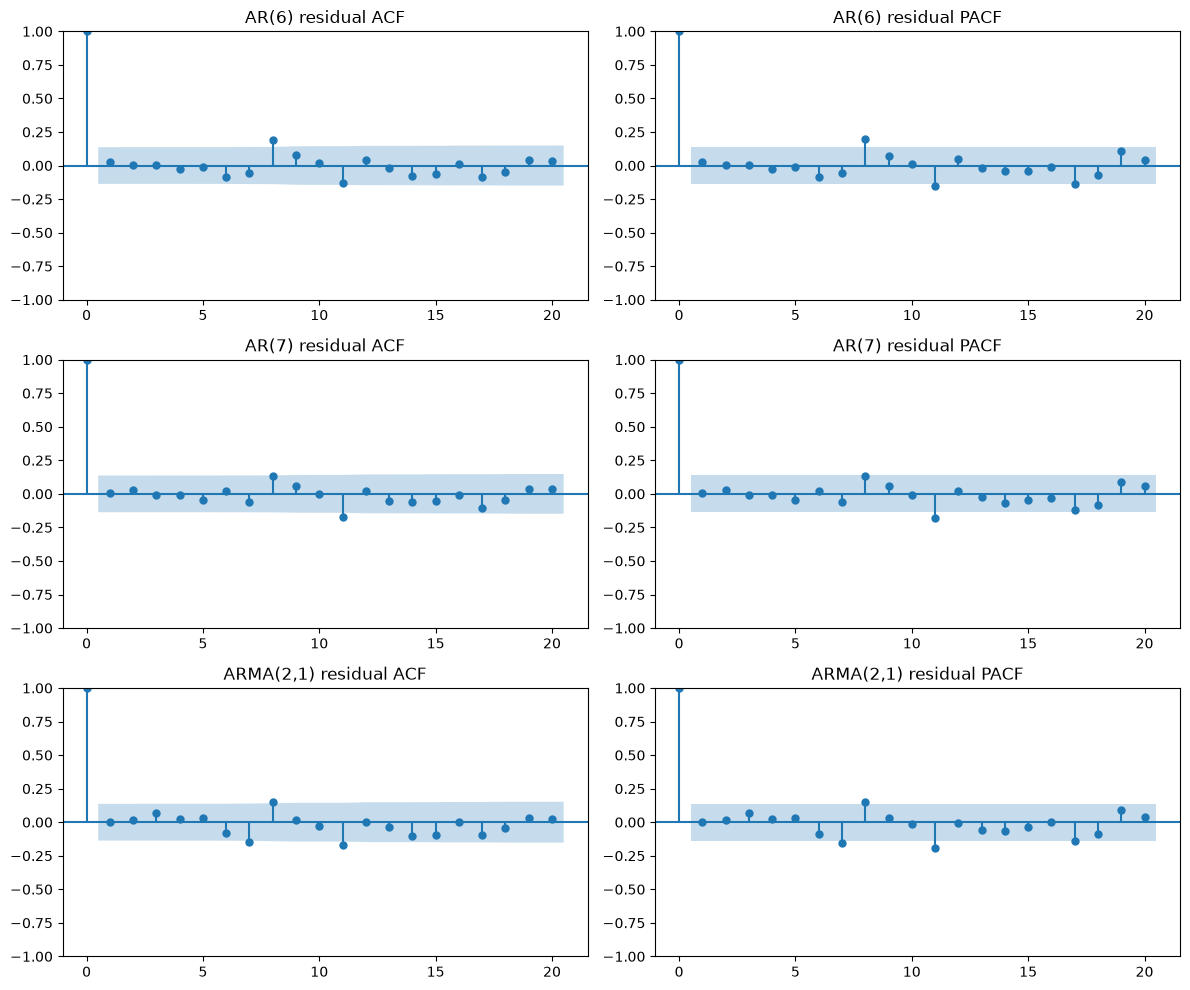

In [29]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

target_models = {
    'AR(6)': (6, 0, 0),
    'AR(7)': (7, 0, 0),
    'ARMA(2,1)': (2, 0, 1),
}

fits = {name: ARIMA(series, order=order).fit() for name, order in target_models.items()}

# ---------- 1. 残差のACF/PACFを並べて描画 ----------
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for i, (name, fit) in enumerate(fits.items()):
    resid = fit.resid.dropna()
    plot_acf(resid, lags=20, ax=axes[i, 0])
    axes[i, 0].set_title(f'{name} residual ACF')
    plot_pacf(resid, lags=20, ax=axes[i, 1], method='ywm')
    axes[i, 1].set_title(f'{name} residual PACF')

plt.tight_layout()
plt.show()

In [ ]:
# Ljung-Box検定をより細かいラグで実施

lb_results = {}
for name, fit in fits.items():
    resid = fit.resid.dropna()
    lb = acorr_ljungbox(resid, lags=list(range(1, 21)), return_df=True)
    lb_results[name] = lb['lb_pvalue']

lb_pvalue_df = pd.DataFrame(lb_results)
lb_pvalue_df.index.name = 'lag'
lb_pvalue_df.round(4)

,AR(6),AR(7),"ARMA(2,1)"
lag,,,
1,0.7327,0.9625,0.9957
2,0.9425,0.9301,0.9763
3,0.9893,0.9851,0.7735
4,0.9903,0.9968,0.8721
5,0.9970,0.9843,0.9209
6,0.9247,0.9930,0.8173
7,0.9162,0.9815,0.3857
8,0.2274,0.6989,0.1454
9,0.2207,0.7091,0.2039


上の結果は、帰無仮説「ラグ 1~k までの自己相関が同時にゼロ」のもとでのp値を表している。p値が0.05を下回るラグが出てきた時点で、そのラグまでの範囲に系列相関が残っていることが示唆される。

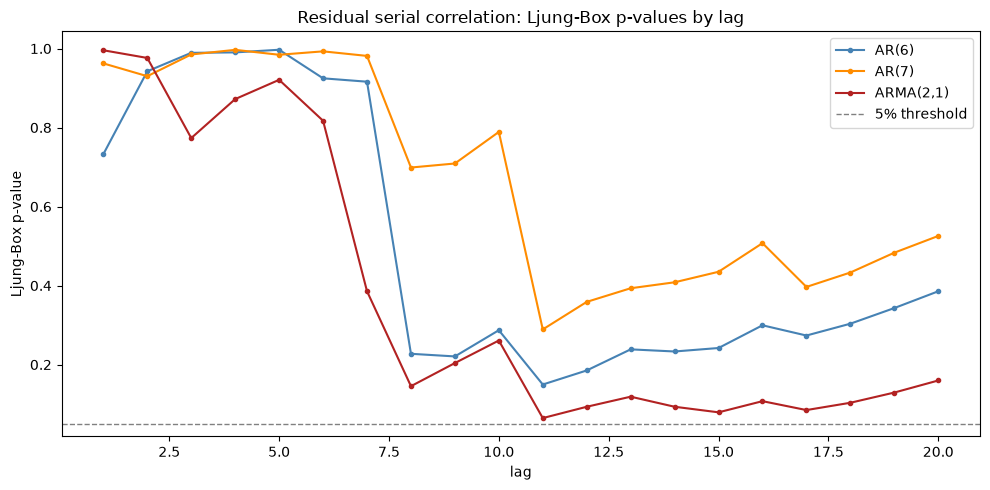

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

colors = {'AR(6)': 'steelblue', 'AR(7)': 'darkorange', 'ARMA(2,1)': 'firebrick'}
for name in lb_pvalue_df.columns:
    ax.plot(lb_pvalue_df.index, lb_pvalue_df[name], marker='o', markersize=3,
            label=name, color=colors.get(name))

ax.axhline(y=0.05, color='gray', linestyle='--', linewidth=1, label='5% threshold')
ax.set_xlabel('lag')
ax.set_ylabel('Ljung-Box p-value')
ax.set_title('Residual serial correlation: Ljung-Box p-values by lag')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

- 3つの図および表から読み取れること
- AR(6),AR(7),ARMA(2,1) の3モデルともラグ8とラグ11に共通してスパイクが見られる。個々のスパイクとしては1本ずつなので、これだけでは統計的に強い結論とは言えないが、3モデル共通で同じラグに現れているのは偶然とは考えにくい。ただ、四半期データであれば8期は2年であるものの11期には特段の周期的意味は薄いため、外れ値由来の可能性が高いと考えられる。
- モデルを比較すると ARMA(2,1) は他のモデルと比べてp値が小さく10％水準であれば11期以降はほとんど帰無仮説を棄却できてしまう。したがって、残差診断の観点から ARMA(2,1) は懸念が残る。

#### 外れ値を考慮する

In [ ]:
# 外れ値を検出する ARMA(2,1)

import numpy as np

resid = fit.resid.dropna()  # fit には AR(6),AR(7), ARMA(2,1) の順で格納されているので、最後の fit は ARMA(2,1) の残差を指す
std_resid = resid / resid.std()  

# 標準残差が3を超える時点を検出
outlier_dates = std_resid[np.abs(std_resid) > 3].index 
print(outlier_dates)

DatetimeIndex(['1980-10-01', '1981-10-01', '1982-07-01'], dtype='datetime64[us]', freq=None)


- 階差をとった図において大きなジャンプがあった時点と整合的である。

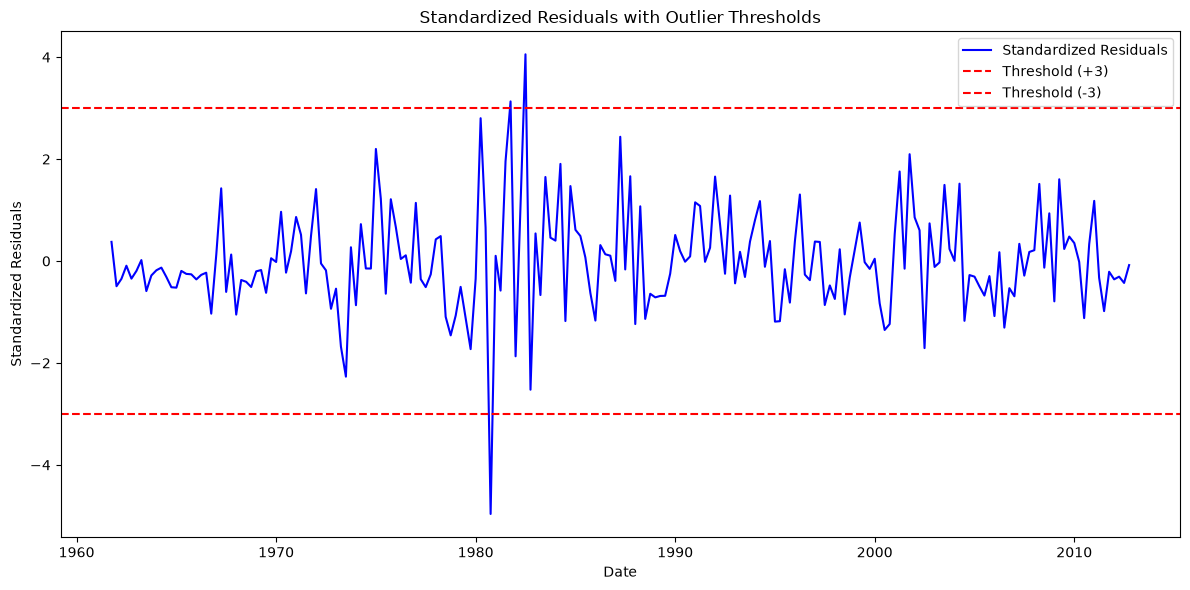

In [ ]:
# ARMA(2,1) の標準残差

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(std_resid.index, std_resid, label='Standardized Residuals', color='blue')
ax.axhline(y=3, color='red', linestyle='--', label='Threshold (+3)')
ax.axhline(y=-3, color='red', linestyle='--', label='Threshold (-3)')
ax.set_title('Standardized Residuals with Outlier Thresholds')
ax.set_xlabel('Date')
ax.set_ylabel('Standardized Residuals')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [34]:
# 外れ値の時点をダミー変数としてモデル化

from statsmodels.tsa.arima.model import ARIMA

exog = pd.DataFrame(0, index=series.index, columns=['outlier_dummy'])
exog.loc[outlier_dates, 'outlier_dummy'] = 1

model_with_outlier = ARIMA(series, order=(2, 0, 1), exog=exog)
fit_with_outlier = model_with_outlier.fit()


resid_with_outlier = fit_with_outlier.resid.dropna()
std_resid_with_outlier = resid_with_outlier / resid_with_outlier.std()

outlier_dates_with_outlier_model = std_resid_with_outlier[np.abs(std_resid_with_outlier) > 3].index
print(outlier_dates_with_outlier_model)

DatetimeIndex(['1980-10-01', '1982-07-01'], dtype='datetime64[us]', freq=None)


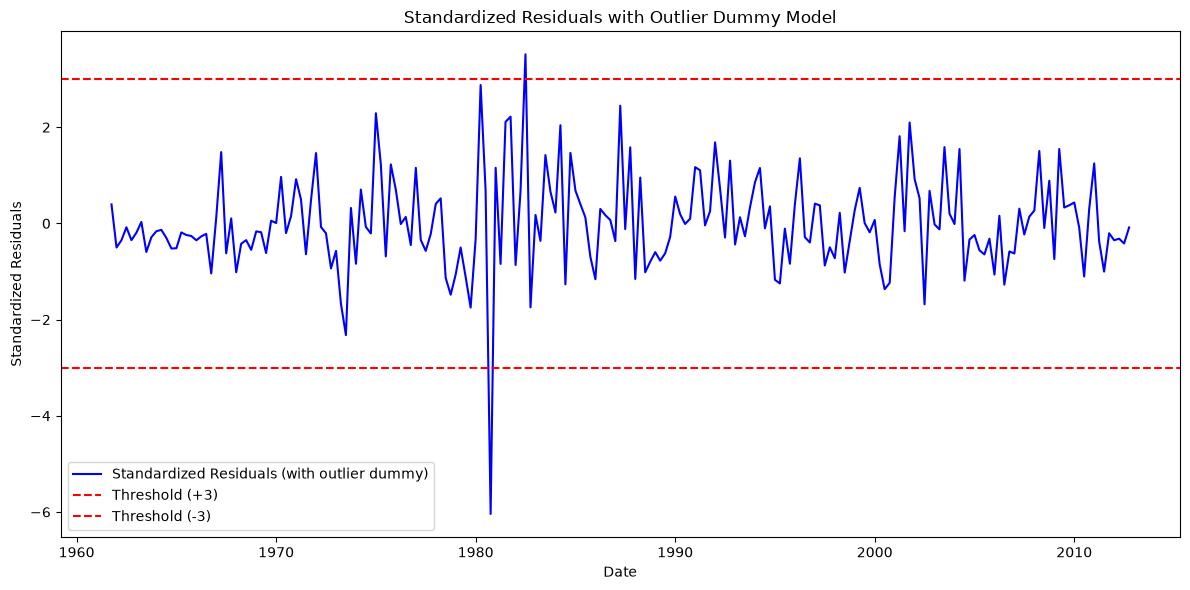

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(std_resid_with_outlier.index, std_resid_with_outlier, label='Standardized Residuals (with outlier dummy)', color='blue')
ax.axhline(y=3, color='red', linestyle='--', label='Threshold (+3)')
ax.axhline(y=-3, color='red', linestyle='--', label='Threshold (-3)')
ax.set_title('Standardized Residuals with Outlier Dummy Model')
ax.set_xlabel('Date')
ax.set_ylabel('Standardized Residuals')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

- 1980Q4, 1982Q3 は依然として外れ値となっている。

In [36]:
# 外れ値を考慮したモデルのパラメータ推定結果を表示

print(fit_with_outlier.summary())

                               SARIMAX Results                                
Dep. Variable:                 spread   No. Observations:                  205
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -135.267
Date:                Thu, 13 Aug 2026   AIC                            282.533
Time:                        05:09:32   BIC                            302.471
Sample:                    10-01-1961   HQIC                           290.598
                         - 10-01-2012                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.1955      0.238      5.019      0.000       0.729       1.662
outlier_dummy     0.4430      0.088      5.007      0.000       0.270       0.616
ar.L1             0.4955      0.179     

In [39]:
# 純粋な ARMA(2,1) モデルのパラメータ推定結果を表示（再掲）

result_df[['ARMA(2,1)']]

,"ARMA(2,1)"
const,1.2021 (0.2156)***
ar.L1,0.4171 (0.1367)***
ar.L2,0.3158 (0.1281)**
ar.L3,NaN
ar.L4,NaN
ar.L5,NaN
ar.L6,NaN
ar.L7,NaN
ma.L1,0.6956 (0.1136)***
ma.L2,NaN


- 情報量基準はすべてにおいて外れ値を考慮したモデルのほうが小さい。

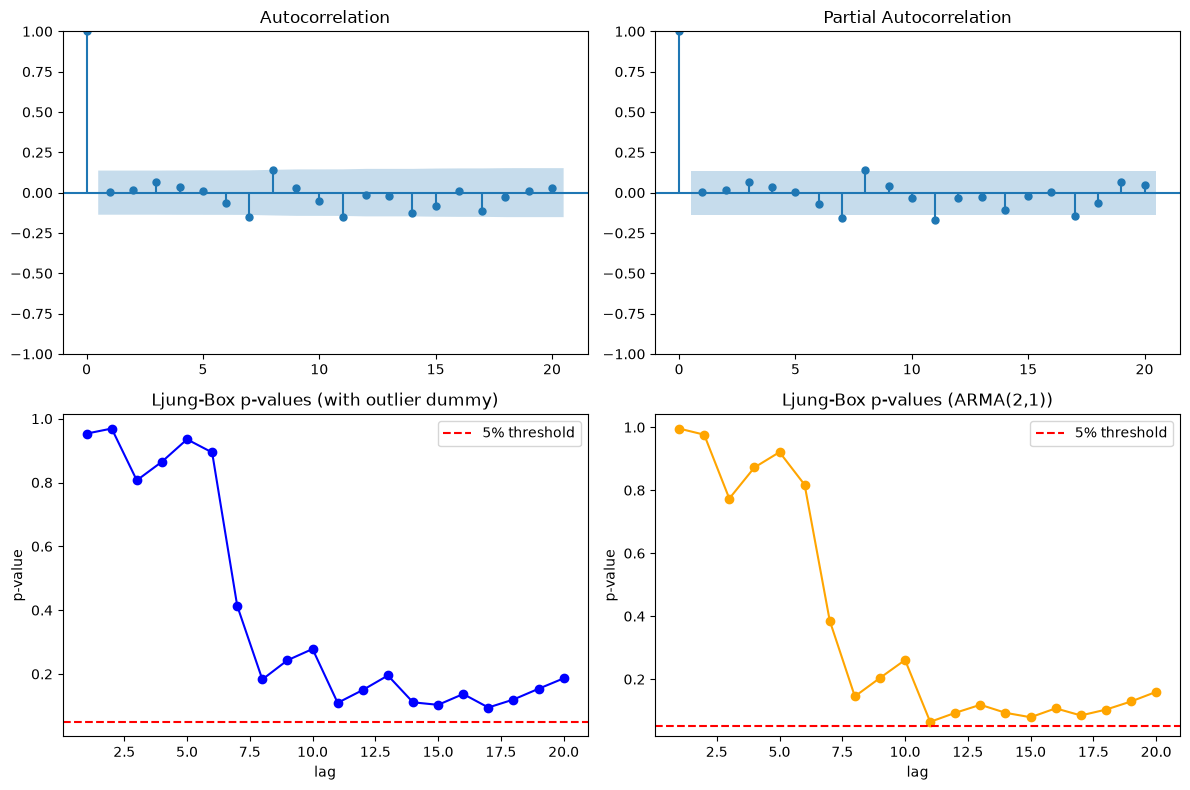

In [41]:
# もう一度 Ljung-Box 検定を実施して、外れ値を考慮したモデルの残差の自己相関を確認

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(std_resid_with_outlier, ax=axes[0, 0], lags=20)
plot_pacf(std_resid_with_outlier, ax=axes[0, 1], lags=20)

lb_with_outlier = acorr_ljungbox(std_resid_with_outlier, lags=list(range(1, 21)), return_df=True)
axes[1, 0].plot(lb_with_outlier.index, lb_with_outlier['lb_pvalue'], marker='o', color='blue')
axes[1, 0].axhline(y=0.05, color='red', linestyle='--', label='5% threshold')
axes[1, 0].set_title('Ljung-Box p-values (with outlier dummy)')
axes[1, 0].set_xlabel('lag')
axes[1, 0].set_ylabel('p-value')
axes[1, 0].legend(loc='best')

axes[1, 1].plot(lb_pvalue_df.index, lb_pvalue_df['ARMA(2,1)'], marker='o', color='orange')
axes[1, 1].axhline(y=0.05, color='red', linestyle='--', label='5% threshold')
axes[1, 1].set_title('Ljung-Box p-values (ARMA(2,1))')
axes[1, 1].set_xlabel('lag')
axes[1, 1].set_ylabel('p-value')
axes[1, 1].legend(loc='best')

plt.tight_layout()
plt.show()

- p値は改善されないものの情報量基準は小さくなっているのでより予測に適していると思われる。

### 予測

- AR(6),AR(7),ARMA(2,1) の予測精度を比較する。

In [ ]:

# 1. ローリング1期先予測

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

n_test = 50
model_configs = {
    'AR(6)': (6, 0, 0),
    'AR(7)': (7, 0, 0),
    'ARMA(2,1)': (2, 0, 1),
}

# 予測を格納する箱
forecast_results = {name: [] for name in model_configs.keys()}
actuals = []

for t in range(len(series) - n_test, len(series)):
    train_t = series.iloc[:t]  # t期時点までのデータで推定
    actual_t = series.iloc[t]  # 実際のt期の値
    actuals.append(actual_t)

    for name, order in model_configs.items():
        fit = ARIMA(train_t, order=order).fit()
        fc = fit.get_forecast(steps=1)
        forecast_results[name].append(fc.predicted_mean.iloc[0])

forecast_df = pd.DataFrame(forecast_results, index=series.index[-n_test:])
forecast_df['actual'] = actuals


In [43]:
# 2. Mincer-Zarnowitz回帰を用いてバイアスがあるかどうか検定

"""
s_t = α + β * f_it + u_t 
という回帰を各 i について行い、帰無仮説 H_0: α = 0, β = 1 を検定することで、予測値がバイアスを持たないかどうかを確認する。
"""

mz_results = {}

for name in model_configs.keys():
    y = forecast_df['actual']
    X = sm.add_constant(forecast_df[name])  # 定数項を追加

    mz_model = sm.OLS(y, X).fit()

    # 結合仮説 H0: alpha=0, beta=1 を検定（F検定）
    hypothesis = f'const = 0, {name} = 1'
    f_test = mz_model.f_test(hypothesis)

    mz_results[name] = {
        'alpha (const)': mz_model.params['const'],
        'alpha_se': mz_model.bse['const'],
        'beta (coef)': mz_model.params[name],
        'beta_se': mz_model.bse[name],
        'F_stat': f_test.fvalue,
        'F_pvalue': f_test.pvalue,
        'R2': mz_model.rsquared,
    }

mz_df = pd.DataFrame(mz_results).T
mz_df.round(4)

,alpha (const),alpha_se,beta (coef),beta_se,F_stat,F_pvalue,R2
AR(6),0.0184,0.1147,0.9916,0.0782,0.0143,0.9858,0.7700
AR(7),0.0447,0.1150,0.9738,0.0783,0.0757,0.9272,0.7632
"ARMA(2,1)",-0.0012,0.1153,1.0068,0.0789,0.0112,0.9889,0.7724


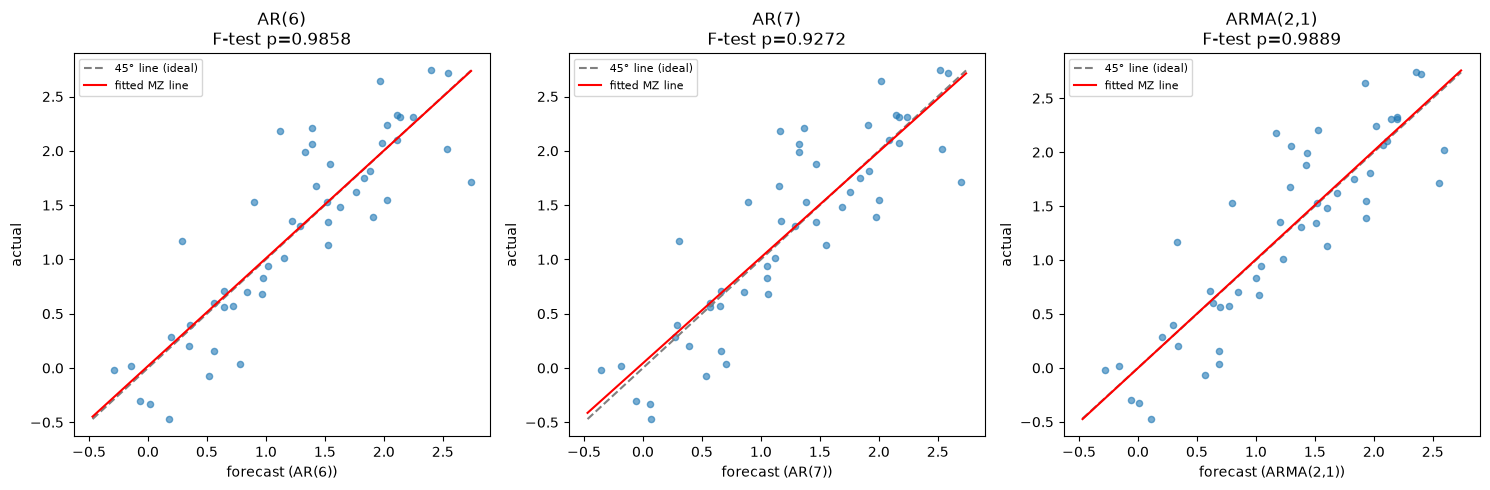

In [ ]:
# 3. 結果の可視化

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, name in zip(axes, model_configs.keys()):
    ax.scatter(forecast_df[name], forecast_df['actual'], alpha=0.6, s=20)

    lims = [min(forecast_df[name].min(), forecast_df['actual'].min()),
            max(forecast_df[name].max(), forecast_df['actual'].max())]
    ax.plot(lims, lims, color='gray', linestyle='--', label='45° line (ideal)')

    # 実際の回帰直線
    alpha = mz_df.loc[name, 'alpha (const)']
    beta = mz_df.loc[name, 'beta (coef)']
    x_range = np.array(lims)
    ax.plot(x_range, alpha + beta * x_range, color='red', label='fitted MZ line')

    ax.set_xlabel(f'forecast ({name})')
    ax.set_ylabel('actual')
    ax.set_title(f'{name}\nF-test p={mz_df.loc[name, "F_pvalue"]:.4f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [45]:
# 4. 予測精度を評価

def compute_metrics(actual, predicted):
    error = actual - predicted
    return {'MAE': np.mean(np.abs(error)), 'RMSE': np.sqrt(np.mean(error**2))}

acc_metrics = {name: compute_metrics(forecast_df['actual'], forecast_df[name]) for name in model_configs.keys()}
pd.DataFrame(acc_metrics).T.round(4)

,MAE,RMSE
AR(6),0.3162,0.4198
AR(7),0.3286,0.4265
"ARMA(2,1)",0.3275,0.4175


- ARMA(2,1) が予測に関して言えば最適

バイアス（不偏性）は、予測が実績値から系統的にずれているかを問う性質である。$$Bias = \mathbb{E}[s_t - f_{i,t}]$$つまり誤差の平均がゼロから離れているかどうか。もし $\alpha > 0$ ならモデルは常に業績より低めに予測してしまう傾向がある過少予測バイアスとなる。$\beta < 1$ ならモデルは変動を小さく見積もりすぎる傾向があり、逆に $\beta > 1$ なら変動に過大に反応していることになる。  
バイアスがあっても、個々の予測誤差は互いに打ち消し合って**平均的には**小さく見えることがある。
<br>
一方、予測精度は、個々の予測が実績からどれだけ離れているか、その大きさそのものを問うている。$$RMSE = \sqrt{\mathbb{E}[(s_t - f_{i,t})^2 ]}$$これはバイアスの有無に関わらず、予測誤差のばらつきの大きさを測っている。バイアスがゼロ（平均的には正しい）であっても、個々の予測が実績から大きく外れたり当たったりを繰り返していれば、精度は低くなる。  
以下のようにRMSEはバイアスと分散に分解できる。$$\mathbb{E}[(s_t - f_{i,t})^2] = \underbrace{(\mathbb{E}[s_t - f_{i,t}])^2}_{\text{バイアスの2乗}} + \underbrace{Var(s_t - f_{i,t})}_{\text{誤差の分散}}$$つまり平均2乗誤差は、バイアスの2乗と、誤差のばらつき（分散）の和に分解できる。

### Appendix

#### matplotlib

matplotolib の描画は、次の３層のオブジェクト階層で構成されている。  
```mermaid
flowchart LR
    Figure --> Axes --> Artist
```
`Figure` は図全体のキャンパス、余白、サイズを管理する。`Axes` は一つのプロット領域の軸、目盛り、データ描画を管理する。`Artist` は実際に描かれる要素：Line2D, Text, Patch などを管理する。  


`fig, ax = plt.subplots()` を実行すると、`fig` は「紙全体」、`ax` は「その紙に置かれた一つのグラフ領域」を表す**オブジェクト**として返ってくる。  
重要なのは、`ax` が単なる関数の呼び出しの対象ではなく、状態（データ範囲、目盛り設定、描画済みの線のリストなど）を保持するオブジェクトであるという点。
<br>
|分類|役割|代表例|
|---|---|---|
|描画系|データから Artist を生成し追加する|`plot`,`scatter`,`bar`,`hist`,`fill_between`|
|設定系|Axes の属性（軸範囲、ラベル、目盛り）を読み書きする|`set_xlabel`,`set_ylim`,`set_title`|
|軸オブジェクト経由の詳細操作|`ax.xaxis`/`ax.yaxis` というサブオブジェクトを介した細かい制御|`ax.xaxis.set_major_locater(...)`|
|注釈・補助線系|データそのものではなく補助的な図形・文字を追加する|`axhline`,`axvline`,`annotate`,`text`,`axvspan`|  

スタンダードな型

```python
import matplotlib.pyplot as plt

# 1. Figure と Axes を作る（土台）
fig, ax = plt.subplots(figsize=(10, 5))

# 2. データを描画する（Artistを追加）
ax.plot(x, y, label='series A')

# 3. 軸・見た目を設定する（Axesの状態を調整）
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('title')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# 4. 仕上げ・出力
plt.tight_layout()
plt.show()  # または plt.savefig('out.png', dpi=300)
```

#### statsmodels

- ACF,PACF
<br>
`plot_acf`,`plot_pacf` の引数に `dropna()` が必要なのは、ACF・PACFの計算では階差を取ることによって系列の先頭に `NaN` を含んでしまうため。  
PACFの `method='ywm'` は計算方法に Yule-Walker法を指定している。ほかにもOLS法、Levinson-Durbin法などがある。  
statsmodels では信頼区間は、Bartlett's formula によって求められる。